<a href="https://colab.research.google.com/github/J05ia5/ML-lab/blob/main/LAB_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **1. Inicialización y Configuración del Entorno**

Este bloque importa las librerías necesarias y configura el dispositivo (GPU si está disponible, de lo contrario CPU) para asegurar la eficiencia computacional durante el entrenamiento de los modelos.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import os

# Configurar el dispositivo (GPU si está disponible, si no, CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando el dispositivo: {device}")

Usando el dispositivo: cuda


### **2. Carga y Preprocesamiento del Dataset Covtype**

Aquí se descarga el dataset `covtype`, se separan las características (X) del objetivo (y), se ajustan las etiquetas para PyTorch, se divide en conjuntos de entrenamiento y prueba, y se escalan los datos usando `StandardScaler` para normalizar las características.

In [2]:
print("Descargando y cargando el dataset covtype...")
covtype = fetch_covtype()

# Extraer features (X) y targets (y)
X = covtype.data
# PyTorch CrossEntropyLoss requiere que las clases vayan de 0 a C-1.
# covtype va de 1 a 7, así que restamos 1.
y = covtype.target - 1

# División en Train y Test (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalización de los datos (Vital para redes neuronales)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Tamaño de entrenamiento: X={X_train.shape}, y={y_train.shape}")
print(f"Tamaño de prueba: X={X_test.shape}, y={y_test.shape}")

Descargando y cargando el dataset covtype...
Tamaño de entrenamiento: X=(464809, 54), y=(464809,)
Tamaño de prueba: X=(116203, 54), y=(116203,)


### **3. Creación de Datasets y DataLoaders para Covtype**

Se define una clase `CovTypeDataset` personalizada para manejar la carga de datos de manera eficiente. Luego, se crean instancias de `Dataset` y `DataLoader` para los conjuntos de entrenamiento y prueba, lo que permite iterar los datos en batches para el entrenamiento del modelo.

In [3]:
# --- APLICANDO CUADERNILLO 03: CLASE DATASET ---
class CovTypeDataset(Dataset):
    def __init__(self, X_data, y_data):
        # Convertimos los arrays de numpy a tensores de PyTorch
        self.X = torch.tensor(X_data, dtype=torch.float32)
        self.y = torch.tensor(y_data, dtype=torch.long) # long es necesario para clasificación

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Instanciamos los datasets
train_dataset = CovTypeDataset(X_train, y_train)
test_dataset = CovTypeDataset(X_test, y_test)

# --- APLICANDO CUADERNILLO 03: DATALOADER ---
# Usamos un batch_size grande (1024) porque el dataset tiene casi 600,000 registros
BATCH_SIZE = 1024

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders creados con éxito.")

DataLoaders creados con éxito.


### **4. Definición del Modelo de Clasificación Covtype**

Este bloque define la arquitectura de la red neuronal `CovTypeNN` para el problema de clasificación multiclase. Se utilizan capas densas (`nn.Linear`) y funciones de activación ReLU para aprender patrones complejos en los datos.

In [4]:
# --- APLICANDO CUADERNILLO 02: REDES NEURONALES CUSTOM ---
class CovTypeNN(nn.Module):
    def __init__(self, input_size=54, num_classes=7):
        super(CovTypeNN, self).__init__()
        # Definimos las capas de la red
        self.fc1 = nn.Linear(input_size, 128)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64, num_classes) # Salida: 7 clases

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x) # No aplicamos Softmax aquí porque CrossEntropyLoss ya lo incluye
        return x

# Instanciar el modelo y enviarlo a la GPU
model = CovTypeNN().to(device)
print(model)

CovTypeNN(
  (fc1): Linear(in_features=54, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=7, bias=True)
)


### **5. Entrenamiento, Validación y Checkpointing del Modelo Covtype**

Se configuran los hiperparámetros, la función de pérdida (`CrossEntropyLoss`) y el optimizador (`Adam`). El bucle de entrenamiento incluye fases de forward y backward pass, cálculo de pérdida y precisión, y la implementación de un sistema de checkpoint para guardar el mejor modelo basado en la precisión de validación.

Iniciando el entrenamiento...
Epoch 1/10 | Loss Train: 0.7112 | Val Acc: 0.7544 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor_modelo_covtype.pt)
Epoch 2/10 | Loss Train: 0.5440 | Val Acc: 0.7737 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor_modelo_covtype.pt)
Epoch 3/10 | Loss Train: 0.5014 | Val Acc: 0.7896 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor_modelo_covtype.pt)
Epoch 4/10 | Loss Train: 0.4688 | Val Acc: 0.8056 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor_modelo_covtype.pt)
Epoch 5/10 | Loss Train: 0.4437 | Val Acc: 0.8154 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor_modelo_covtype.pt)
Epoch 6/10 | Loss Train: 0.4242 | Val Acc: 0.8221 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor_modelo_covtype.pt)
Epoch 7/10 | Loss Train: 0.4077 | Val Acc: 0.8335 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor_modelo_covtype.pt)
Epoch 8/10 | Loss Train: 0.3952 | Val Acc: 0.8369 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor_modelo_covtype.pt)
Epoch 9/10 | Loss Train: 0.3847 | Val Acc: 0.8425 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor

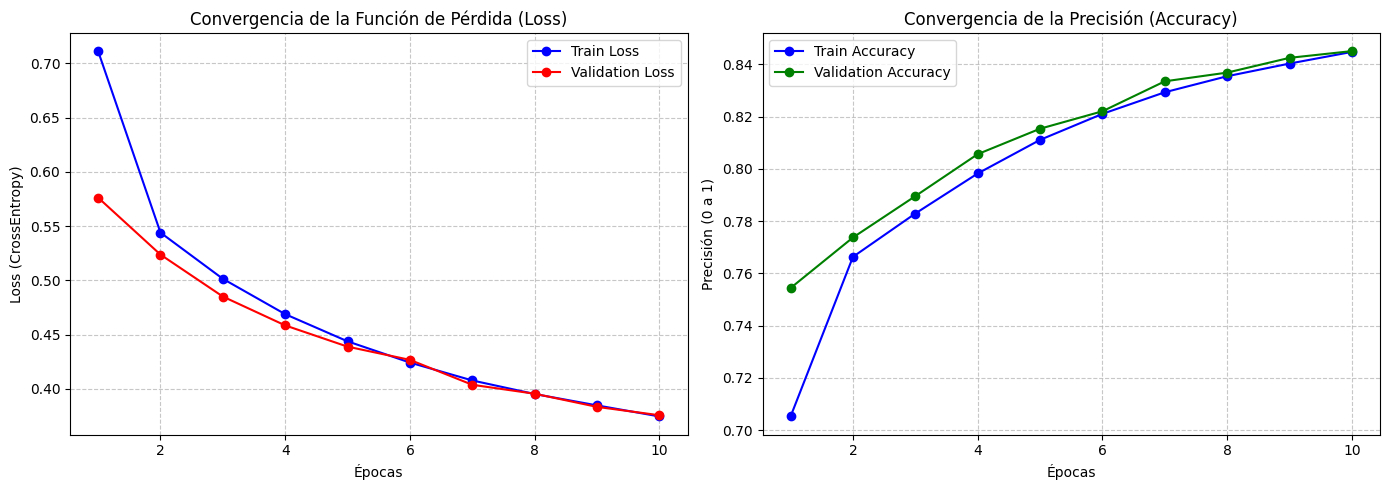

In [5]:
import matplotlib.pyplot as plt # Importamos matplotlib para las gráficas

# Definir hiperparámetros, función de pérdida y optimizador
epochs = 10
criterion = nn.CrossEntropyLoss()
# Usamos Adam en lugar de SGD (suele converger más rápido)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- APLICANDO CUADERNILLO 04: GUARDADO DE MODELOS (CHECKPOINTS) ---
PATH_CHECKPOINT = "./mejor_modelo_covtype.pt"
best_acc = 0.0

# 1. LISTAS PARA GUARDAR EL HISTORIAL Y GRAFICAR DESPUÉS
history_train_loss = []
history_val_loss = []
history_train_acc = []
history_val_acc = []

print("Iniciando el entrenamiento...")

for epoch in range(1, epochs + 1):
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    train_loss = []
    train_acc = [] # Añadimos lista para precisión de entrenamiento

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Forward pass
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        # Backward pass y optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss.append(loss.item())

        # Calcular precisión de entrenamiento en este batch
        acc = (y_batch == torch.argmax(y_pred, axis=1)).sum().item() / len(y_batch)
        train_acc.append(acc)

    # --- FASE DE VALIDACIÓN ---
    model.eval()
    val_loss = [] # Añadimos lista para el loss de validación
    val_acc = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            y_pred = model(X_batch)

            # Calcular Loss de validación
            v_loss = criterion(y_pred, y_batch)
            val_loss.append(v_loss.item())

            # Calcular precisión
            acc = (y_batch == torch.argmax(y_pred, axis=1)).sum().item() / len(y_batch)
            val_acc.append(acc)

    # Calcular promedios de la época
    avg_train_loss = np.mean(train_loss)
    avg_train_acc = np.mean(train_acc)
    avg_val_loss = np.mean(val_loss)
    avg_val_acc = np.mean(val_acc)

    # 2. GUARDAR LOS PROMEDIOS EN EL HISTORIAL
    history_train_loss.append(avg_train_loss)
    history_val_loss.append(avg_val_loss)
    history_train_acc.append(avg_train_acc)
    history_val_acc.append(avg_val_acc)

    # --- APLICANDO CUADERNILLO 04: GUARDAR SI MEJORA ---
    if avg_val_acc > best_acc:
        best_acc = avg_val_acc
        torch.save(model.state_dict(), PATH_CHECKPOINT)
        estado_guardado = f"--> ¡NUEVO CHECKPOINT GUARDADO! ({PATH_CHECKPOINT})"
    else:
        estado_guardado = ""

    print(f"Epoch {epoch}/{epochs} | Loss Train: {avg_train_loss:.4f} | Val Acc: {avg_val_acc:.4f} {estado_guardado}")

print("\nEntrenamiento finalizado. Generando gráficas de convergencia...")

# --- 3. SECCIÓN DE GRAFICADO ---
# Creamos una figura con 2 subgráficos (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Función de Pérdida (Loss)
ax1.plot(range(1, epochs + 1), history_train_loss, label='Train Loss', color='blue', marker='o')
ax1.plot(range(1, epochs + 1), history_val_loss, label='Validation Loss', color='red', marker='o')
ax1.set_title('Convergencia de la Función de Pérdida (Loss)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Loss (CrossEntropy)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfica 2: Precisión (Accuracy)
ax2.plot(range(1, epochs + 1), history_train_acc, label='Train Accuracy', color='blue', marker='o')
ax2.plot(range(1, epochs + 1), history_val_acc, label='Validation Accuracy', color='green', marker='o')
ax2.set_title('Convergencia de la Precisión (Accuracy)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Precisión (0 a 1)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### **6. Recuperación y Evaluación del Modelo Covtype Guardado**

Este bloque demuestra cómo cargar un modelo previamente entrenado y guardado desde un checkpoint. Se instancia un nuevo modelo y se cargan sus pesos para verificar que el modelo recuperado mantiene el rendimiento esperado.

In [6]:
# --- DEMOSTRACIÓN DEL CUADERNILLO 04 ---
print("\n--- Simulando reinicio del sistema ---")
# Instanciamos un modelo completamente nuevo (pesos aleatorios)
modelo_recuperado = CovTypeNN().to(device)

# Cargamos los pesos guardados en el archivo .pt
modelo_recuperado.load_state_dict(torch.load(PATH_CHECKPOINT))
modelo_recuperado.eval()

print("Modelo recuperado exitosamente desde el checkpoint.")

# Probamos el modelo recuperado
acc_recuperada = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = modelo_recuperado(X_batch)
        acc = (y_batch == torch.argmax(y_pred, axis=1)).sum().item() / len(y_batch)
        acc_recuperada.append(acc)

print(f"Precisión del modelo recuperado: {np.mean(acc_recuperada):.5f}")


--- Simulando reinicio del sistema ---
Modelo recuperado exitosamente desde el checkpoint.
Precisión del modelo recuperado: 0.84511


### **7. Inicio de la Sección: Clasificación Binaria (Dataset Asteroid)**

Este marcador indica el comienzo de un nuevo problema, enfocado en la clasificación binaria de asteroides.

In [7]:
# clasificacion binaria

### **8. Carga y Preprocesamiento del Dataset Asteroid**

Se carga el dataset de asteroides, se realiza una limpieza de datos (filtrado de columnas relevantes, mapeo binario, manejo de valores nulos, one-hot encoding), se separan las características y el objetivo, se divide en conjuntos de entrenamiento y prueba, y se escalan los datos.

In [10]:
# leemos el dataset
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

print("--- CLASIFICACIÓN BINARIA: ASTEROID DATASET ---")

# 1. Cargar el dataset (asegúrate de tener Google Drive montado)
# Cambia la ruta si es necesario
ruta_csv = "/content/drive/MyDrive/Ciencias de la Computacion USFX/Quinto Semestre/AI/MyDatasets/asteroid.csv"
df_asteroid = pd.read_csv(ruta_csv, low_memory=False)

# 2. Replicar tu limpieza de datos del LAB_3
relevant_cols = ['H', 'diameter', 'albedo', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'per_y', 'moid_ld', 'class', 'rms', 'neo', 'pha']
df_filtered = df_asteroid[relevant_cols].copy()

# Mapeo a binario
df_filtered['neo'] = df_filtered['neo'].map({'Y': 1, 'N': 0})
df_filtered['pha'] = df_filtered['pha'].map({'Y': 1, 'N': 0})

# Conversión y limpieza
df_filtered['diameter'] = pd.to_numeric(df_filtered['diameter'], errors='coerce')
df_clean = df_filtered.dropna()

# Muestra de 100,000 registros
df_sample = df_clean.sample(n=min(100000, len(df_clean)), random_state=42)

# One-Hot Encoding
df_final = pd.get_dummies(df_sample, columns=['class'], drop_first=True)

# 3. Separar Features (X) y Target (y)
X_ast = df_final.drop('pha', axis=1).astype(float).values
y_ast = df_final['pha'].astype(float).values # float es necesario para clasif. binaria en PyTorch

# 4. División y Escalado
X_train_ast, X_test_ast, y_train_ast, y_test_ast = train_test_split(X_ast, y_ast, test_size=0.2, random_state=42, stratify=y_ast)

scaler_ast = StandardScaler()
X_train_ast = scaler_ast.fit_transform(X_train_ast)
X_test_ast = scaler_ast.transform(X_test_ast)

print(f"Features de entrada: {X_train_ast.shape[1]}")
print(f"Entrenamiento: X={X_train_ast.shape}, y={y_train_ast.shape}")

Mounted at /content/drive
--- CLASIFICACIÓN BINARIA: ASTEROID DATASET ---
Features de entrada: 27
Entrenamiento: X=(80000, 27), y=(80000,)


### **9. Creación de Datasets y DataLoaders para Asteroid**

Similar al caso de `covtype`, se define una clase `AsteroidDataset` para manejar el dataset de asteroides. Es crucial notar la forma del tensor `y` (`unsqueeze(1)`) para la clasificación binaria en PyTorch, y se crean los `DataLoaders`.

In [11]:
# --- APLICANDO CUADERNILLO 03: CLASE DATASET PARA ASTEROIDES ---
class AsteroidDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X = torch.tensor(X_data, dtype=torch.float32)
        # En clasificación binaria, PyTorch exige que 'y' tenga forma [Batch, 1] y sea float
        self.y = torch.tensor(y_data, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset_ast = AsteroidDataset(X_train_ast, y_train_ast)
test_dataset_ast = AsteroidDataset(X_test_ast, y_test_ast)

BATCH_SIZE_AST = 1024

train_loader_ast = DataLoader(train_dataset_ast, batch_size=BATCH_SIZE_AST, shuffle=True)
test_loader_ast = DataLoader(test_dataset_ast, batch_size=BATCH_SIZE_AST, shuffle=False)

print("DataLoaders del Asteroid Dataset creados.")

DataLoaders del Asteroid Dataset creados.


### **10. Definición del Modelo de Clasificación Binaria Asteroid**

Aquí se define la red neuronal `AsteroidBinaryNN` con una arquitectura adecuada para la clasificación binaria. La capa de salida tiene una única neurona sin función de activación final, ya que `BCEWithLogitsLoss` la aplica internamente para mayor estabilidad numérica.

In [12]:
# --- APLICANDO CUADERNILLO 02: RED NEURONAL BINARIA ---
class AsteroidBinaryNN(nn.Module):
    def __init__(self, input_size):
        super(AsteroidBinaryNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()

        # Una sola neurona de salida para predecir 0 o 1 (No o Sí es peligroso)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        # Nota: No usamos Sigmoid aquí porque la función BCEWithLogitsLoss ya lo aplica internamente (es más estable)
        return x

input_dimension = X_train_ast.shape[1]
model_ast = AsteroidBinaryNN(input_size=input_dimension).to(device)
print(model_ast)

AsteroidBinaryNN(
  (fc1): Linear(in_features=27, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)


### **11. Entrenamiento, Validación y Checkpointing del Modelo Asteroid**

Se configuran los hiperparámetros, la función de pérdida (`BCEWithLogitsLoss`) y el optimizador para el modelo de asteroides. El bucle de entrenamiento sigue la misma lógica de forward/backward pass, cálculo de métricas (pérdida y precisión), y un sistema de checkpoint para guardar el modelo con la mejor precisión de validación.

Entrenando el modelo de Asteroides...
Epoch 1/15 | Loss Train: 0.05700 | Val Acc: 0.99849 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor_modelo_asteroid.pt)
Epoch 2/15 | Loss Train: 0.00295 | Val Acc: 0.99849 
Epoch 3/15 | Loss Train: 0.00282 | Val Acc: 0.99849 
Epoch 4/15 | Loss Train: 0.00294 | Val Acc: 0.99849 
Epoch 5/15 | Loss Train: 0.00293 | Val Acc: 0.99849 
Epoch 6/15 | Loss Train: 0.00289 | Val Acc: 0.99849 
Epoch 7/15 | Loss Train: 0.00268 | Val Acc: 0.99863 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor_modelo_asteroid.pt)
Epoch 8/15 | Loss Train: 0.00270 | Val Acc: 0.99849 
Epoch 9/15 | Loss Train: 0.00264 | Val Acc: 0.99849 
Epoch 10/15 | Loss Train: 0.00263 | Val Acc: 0.99849 
Epoch 11/15 | Loss Train: 0.00260 | Val Acc: 0.99864 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor_modelo_asteroid.pt)
Epoch 12/15 | Loss Train: 0.00257 | Val Acc: 0.99864 
Epoch 13/15 | Loss Train: 0.00265 | Val Acc: 0.99868 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor_modelo_asteroid.pt)
Epoch 14/15 | Loss Train: 0.0

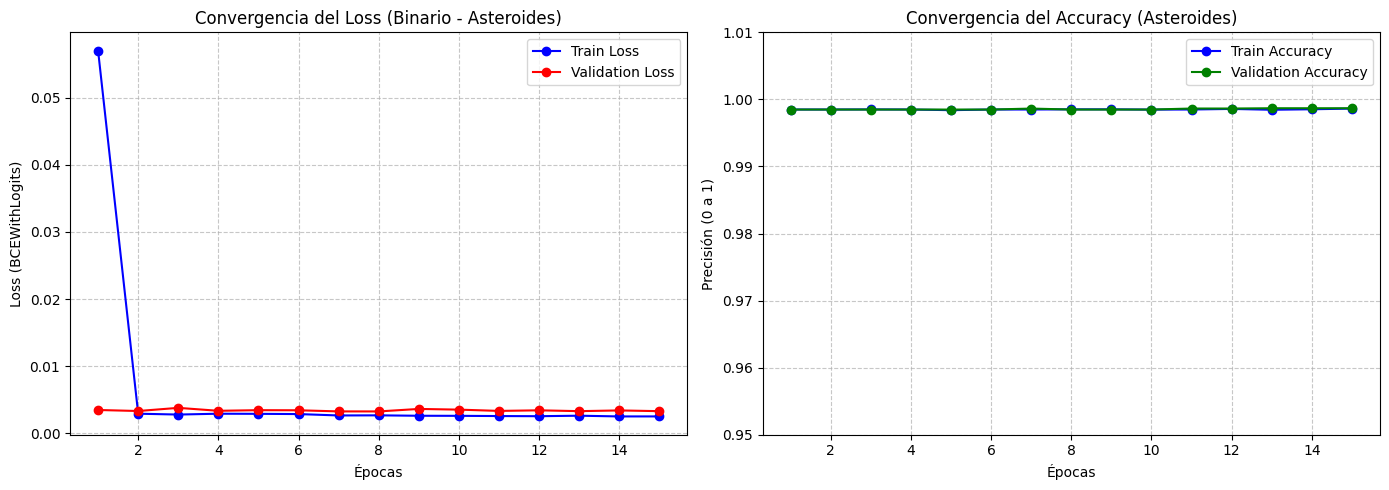

In [13]:
import matplotlib.pyplot as plt

epochs_ast = 15
# BCEWithLogitsLoss es ideal para binario (combina Sigmoid + Binary Cross Entropy)
criterion_ast = nn.BCEWithLogitsLoss()
optimizer_ast = torch.optim.Adam(model_ast.parameters(), lr=0.005)

# --- APLICANDO CUADERNILLO 04: GUARDADO DE MODELOS (CHECKPOINTS) ---
PATH_CHECKPOINT_AST = "./mejor_modelo_asteroid.pt"
best_acc_ast = 0.0

# 1. LISTAS PARA GUARDAR EL HISTORIAL Y GRAFICAR DESPUÉS
history_train_loss_ast = []
history_val_loss_ast = []
history_train_acc_ast = []
history_val_acc_ast = []

print("Entrenando el modelo de Asteroides...")

for epoch in range(1, epochs_ast + 1):
    # --- FASE DE ENTRENAMIENTO ---
    model_ast.train()
    train_loss = []
    train_acc = [] # Añadimos lista para precisión de entrenamiento

    for X_batch, y_batch in train_loader_ast:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Forward pass
        y_pred = model_ast(X_batch)
        loss = criterion_ast(y_pred, y_batch)

        # Backward pass y optimización
        optimizer_ast.zero_grad()
        loss.backward()
        optimizer_ast.step()

        train_loss.append(loss.item())

        # Calcular precisión de entrenamiento en este batch
        y_pred_sig = torch.sigmoid(y_pred)
        predicciones = (y_pred_sig >= 0.5).float()
        acc = (predicciones == y_batch).sum().item() / len(y_batch)
        train_acc.append(acc)

    # --- FASE DE VALIDACIÓN ---
    model_ast.eval()
    val_loss = [] # Añadimos lista para el loss de validación
    val_acc = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader_ast:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            y_pred = model_ast(X_batch)

            # Calcular Loss de validación
            v_loss = criterion_ast(y_pred, y_batch)
            val_loss.append(v_loss.item())

            # Calcular precisión de validación
            y_pred_sig = torch.sigmoid(y_pred)
            predicciones = (y_pred_sig >= 0.5).float()

            acc = (predicciones == y_batch).sum().item() / len(y_batch)
            val_acc.append(acc)

    # Calcular promedios
    avg_train_loss = np.mean(train_loss)
    avg_train_acc = np.mean(train_acc)
    avg_val_loss = np.mean(val_loss)
    avg_val_acc = np.mean(val_acc)

    # 2. GUARDAR LOS PROMEDIOS EN EL HISTORIAL
    history_train_loss_ast.append(avg_train_loss)
    history_val_loss_ast.append(avg_val_loss)
    history_train_acc_ast.append(avg_train_acc)
    history_val_acc_ast.append(avg_val_acc)

    # --- APLICANDO CUADERNILLO 04: GUARDAR SI MEJORA ---
    if avg_val_acc > best_acc_ast:
        best_acc_ast = avg_val_acc
        torch.save(model_ast.state_dict(), PATH_CHECKPOINT_AST)
        estado_guardado = f"--> ¡NUEVO CHECKPOINT GUARDADO! ({PATH_CHECKPOINT_AST})"
    else:
        estado_guardado = ""

    print(f"Epoch {epoch}/{epochs_ast} | Loss Train: {avg_train_loss:.5f} | Val Acc: {avg_val_acc:.5f} {estado_guardado}")

print("\nEntrenamiento finalizado. Generando gráficas de convergencia...")

# --- 3. SECCIÓN DE GRAFICADO ---
# Creamos una figura con 2 subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Función de Pérdida (Loss)
ax1.plot(range(1, epochs_ast + 1), history_train_loss_ast, label='Train Loss', color='blue', marker='o')
ax1.plot(range(1, epochs_ast + 1), history_val_loss_ast, label='Validation Loss', color='red', marker='o')
ax1.set_title('Convergencia del Loss (Binario - Asteroides)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Loss (BCEWithLogits)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfica 2: Precisión (Accuracy)
ax2.plot(range(1, epochs_ast + 1), history_train_acc_ast, label='Train Accuracy', color='blue', marker='o')
ax2.plot(range(1, epochs_ast + 1), history_val_acc_ast, label='Validation Accuracy', color='green', marker='o')
ax2.set_title('Convergencia del Accuracy (Asteroides)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Precisión (0 a 1)')
# Ajustamos el eje Y para que no se vea plano si los valores son 0.999
ax2.set_ylim([0.95, 1.01])
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### **12. Recuperación y Evaluación del Modelo Asteroid Guardado**

Este bloque demuestra la recuperación del modelo de clasificación binaria de asteroides desde su checkpoint. Se carga el estado del modelo y se evalúa su precisión final en el conjunto de prueba, aplicando `sigmoid` a las predicciones para obtener probabilidades y clasificar.

In [14]:
# --- DEMOSTRACIÓN DE RECUPERACIÓN (CUADERNILLO 04) ---
print("\n--- Simulando reinicio: Cargando modelo guardado de Asteroides ---")
modelo_recuperado_ast = AsteroidBinaryNN(input_size=input_dimension).to(device)
modelo_recuperado_ast.load_state_dict(torch.load(PATH_CHECKPOINT_AST))
modelo_recuperado_ast.eval()

# Evaluando precisión final
acc_final = []
with torch.no_grad():
    for X_batch, y_batch in test_loader_ast:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pred_sig = torch.sigmoid(modelo_recuperado_ast(X_batch))
        pred_class = (pred_sig >= 0.5).float()
        acc = (pred_class == y_batch).sum().item() / len(y_batch)
        acc_final.append(acc)

print(f"Precisión del modelo recuperado desde '{PATH_CHECKPOINT_AST}': {np.mean(acc_final)*100:.2f}%")


--- Simulando reinicio: Cargando modelo guardado de Asteroides ---
Precisión del modelo recuperado desde './mejor_modelo_asteroid.pt': 99.87%


### **13. Inicio de la Sección: Regresión Lineal (House Price Dataset)**

Este marcador indica el comienzo de un nuevo problema, enfocado en la regresión para predecir precios de casas.

In [ ]:
# regresion linal

### **14. Carga y Preprocesamiento del Dataset de Precios de Casas**

Se carga el dataset de precios de casas, se eliminan columnas irrelevantes, se separan características y objetivo, se divide en conjuntos de entrenamiento y prueba, y se escalan tanto las características (X) como el objetivo (y) para mejorar la convergencia del modelo.

In [15]:
print("--- REGRESIÓN: HOUSE PRICE DATASET ---")

# 1. Cargar el dataset
ruta_house = "/content/drive/MyDrive/Ciencias de la Computacion USFX/Quinto Semestre/AI/MyDatasets/kc_house_data.csv"
df_house = pd.read_csv(ruta_house)

# 2. Limpieza que hiciste en LAB_2 (Eliminar id y date)
df_house_clean = df_house.drop(['id', 'date'], axis=1)

# 3. Separar Features (X) y Target (y)
X_house = df_house_clean.drop('price', axis=1).values
y_house = df_house_clean['price'].values

# 4. División 80/20
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_house, y_house, test_size=0.2, random_state=42)

# 5. Escalado de Features (X)
scaler_X = StandardScaler()
X_train_h = scaler_X.fit_transform(X_train_h)
X_test_h = scaler_X.transform(X_test_h)

# 6. Escalado del Target (y) -> ¡Vital para que PyTorch aprenda bien precios grandes!
scaler_y = StandardScaler()
# El scaler de sklearn requiere formato de columna (N, 1)
y_train_h = scaler_y.fit_transform(y_train_h.reshape(-1, 1))
y_test_h = scaler_y.transform(y_test_h.reshape(-1, 1))

print(f"Features de entrada: {X_train_h.shape[1]}")
print(f"Tamaño de Entrenamiento: X={X_train_h.shape}, y={y_train_h.shape}")

--- REGRESIÓN: HOUSE PRICE DATASET ---
Features de entrada: 18
Tamaño de Entrenamiento: X=(17290, 18), y=(17290, 1)


### **15. Creación de Datasets y DataLoaders para Precios de Casas**

Se define una clase `HouseDataset` para manejar los datos de precios de casas, asegurando que `X` e `y` sean tensores `float32`. Se crean `DataLoaders` para el entrenamiento y la prueba.

In [16]:
# --- APLICANDO CUADERNILLO 03: DATASET PARA REGRESIÓN ---
class HouseDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X = torch.tensor(X_data, dtype=torch.float32)
        self.y = torch.tensor(y_data, dtype=torch.float32) # y ya tiene forma [Batch, 1] por el scaler

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset_h = HouseDataset(X_train_h, y_train_h)
test_dataset_h = HouseDataset(X_test_h, y_test_h)

BATCH_SIZE_H = 1024
train_loader_h = DataLoader(train_dataset_h, batch_size=BATCH_SIZE_H, shuffle=True)
test_loader_h = DataLoader(test_dataset_h, batch_size=BATCH_SIZE_H, shuffle=False)

print("DataLoaders del House Dataset creados.")

DataLoaders del House Dataset creados.


### **16. Definición del Modelo de Regresión para Precios de Casas**

Este bloque define la arquitectura de la red neuronal `HousePriceNN` para el problema de regresión. La capa de salida tiene una única neurona sin función de activación, lo que permite una salida lineal continua, adecuada para predecir valores numéricos.

In [17]:
# --- APLICANDO CUADERNILLO 02: RED NEURONAL DE REGRESIÓN ---
class HousePriceNN(nn.Module):
    def __init__(self, input_size):
        super(HousePriceNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()

        # Una sola neurona de salida SIN activación (salida lineal continua)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

model_h = HousePriceNN(input_size=X_train_h.shape[1]).to(device)
print(model_h)

HousePriceNN(
  (fc1): Linear(in_features=18, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)


### **17. Entrenamiento, Validación y Checkpointing del Modelo de Precios de Casas**

Se configuran los hiperparámetros, la función de pérdida (`MSELoss` para regresión) y el optimizador. El bucle de entrenamiento calcula el MSE y el MAE, y el sistema de checkpoint guarda el modelo que logra el menor error de validación (MSE).

Entrenando el modelo de Precios de Casas...
Epoch 1/30 | Train MSE: 0.3618 | Val MSE: 0.2766 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor_modelo_house.pt)
Epoch 2/30 | Train MSE: 0.2118 | Val MSE: 0.2241 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor_modelo_house.pt)
Epoch 3/30 | Train MSE: 0.1754 | Val MSE: 0.2070 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor_modelo_house.pt)
Epoch 4/30 | Train MSE: 0.1507 | Val MSE: 0.1869 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor_modelo_house.pt)
Epoch 5/30 | Train MSE: 0.1402 | Val MSE: 0.2055 
Epoch 6/30 | Train MSE: 0.1561 | Val MSE: 0.1919 
Epoch 7/30 | Train MSE: 0.1250 | Val MSE: 0.1643 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor_modelo_house.pt)
Epoch 8/30 | Train MSE: 0.1129 | Val MSE: 0.1639 --> ¡NUEVO CHECKPOINT GUARDADO! (./mejor_modelo_house.pt)
Epoch 9/30 | Train MSE: 0.1047 | Val MSE: 0.1665 
Epoch 10/30 | Train MSE: 0.1024 | Val MSE: 0.1720 
Epoch 11/30 | Train MSE: 0.0965 | Val MSE: 0.1663 
Epoch 12/30 | Train MSE: 0.0920 | Val MSE: 0.1518 --> ¡NUEVO C

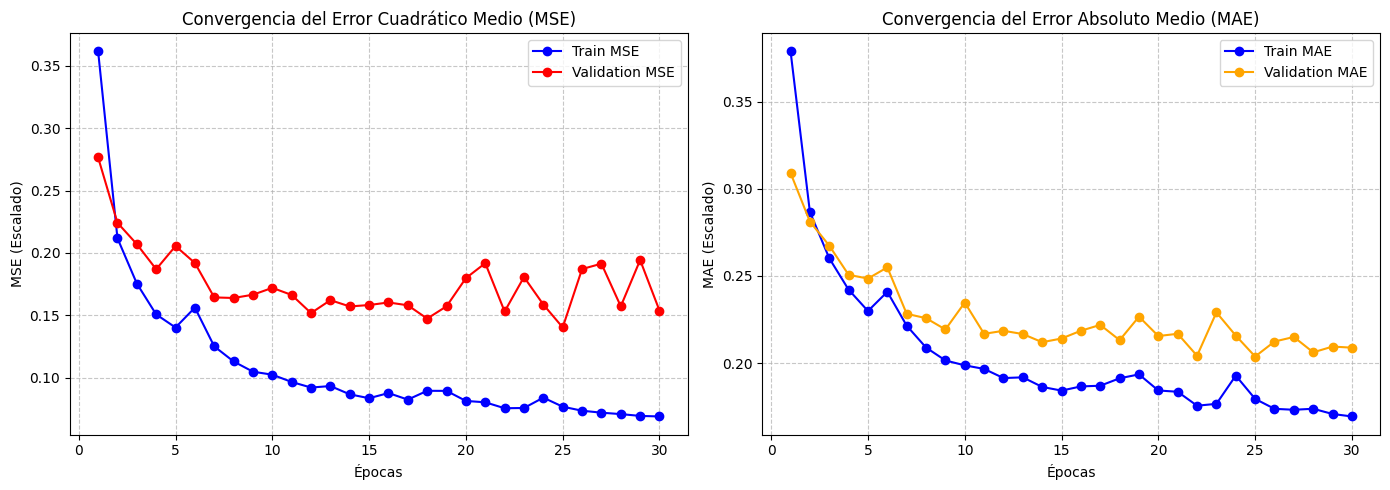

In [18]:
import matplotlib.pyplot as plt

epochs_h = 30
# Función de pérdida para Regresión: MSE (Error Cuadrático Medio)
criterion_h = nn.MSELoss()
optimizer_h = torch.optim.Adam(model_h.parameters(), lr=0.01)

# --- APLICANDO CUADERNILLO 04: GUARDAR EL QUE TENGA MENOR ERROR ---
PATH_CHECKPOINT_H = "./mejor_modelo_house.pt"
best_loss_h = float('inf') # Empezamos con un error infinito

# 1. LISTAS PARA GUARDAR EL HISTORIAL Y GRAFICAR DESPUÉS
history_train_mse = []
history_val_mse = []
history_train_mae = []
history_val_mae = []

print("Entrenando el modelo de Precios de Casas...")

for epoch in range(1, epochs_h + 1):
    # --- FASE DE ENTRENAMIENTO ---
    model_h.train()
    train_loss = []
    train_mae = [] # Lista para el Error Absoluto de entrenamiento

    for X_batch, y_batch in train_loader_h:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Forward pass
        y_pred = model_h(X_batch)

        # Calcular MSE (Loss principal)
        loss = criterion_h(y_pred, y_batch)

        # Backward pass y optimización
        optimizer_h.zero_grad()
        loss.backward()
        optimizer_h.step()

        train_loss.append(loss.item())

        # Calcular MAE (Mean Absolute Error) para monitoreo
        mae = torch.abs(y_pred - y_batch).mean().item()
        train_mae.append(mae)

    # --- FASE DE VALIDACIÓN ---
    model_h.eval()
    val_loss = []
    val_mae = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader_h:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            y_pred = model_h(X_batch)

            # Calcular MSE de validación
            loss = criterion_h(y_pred, y_batch)
            val_loss.append(loss.item())

            # Calcular MAE de validación
            mae = torch.abs(y_pred - y_batch).mean().item()
            val_mae.append(mae)

    # Calcular promedios de la época
    avg_train_loss = np.mean(train_loss)
    avg_val_loss = np.mean(val_loss)
    avg_train_mae = np.mean(train_mae)
    avg_val_mae = np.mean(val_mae)

    # 2. GUARDAR LOS PROMEDIOS EN EL HISTORIAL
    history_train_mse.append(avg_train_loss)
    history_val_mse.append(avg_val_loss)
    history_train_mae.append(avg_train_mae)
    history_val_mae.append(avg_val_mae)

    # --- GUARDAR CHECKPOINT SI EL ERROR DISMINUYE ---
    if avg_val_loss < best_loss_h:
        best_loss_h = avg_val_loss
        torch.save(model_h.state_dict(), PATH_CHECKPOINT_H)
        estado_guardado = f"--> ¡NUEVO CHECKPOINT GUARDADO! ({PATH_CHECKPOINT_H})"
    else:
        estado_guardado = ""

    print(f"Epoch {epoch}/{epochs_h} | Train MSE: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f} {estado_guardado}")

print("\nEntrenamiento finalizado. Generando gráficas de convergencia...")

# --- 3. SECCIÓN DE GRAFICADO ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: MSE (Mean Squared Error)
ax1.plot(range(1, epochs_h + 1), history_train_mse, label='Train MSE', color='blue', marker='o')
ax1.plot(range(1, epochs_h + 1), history_val_mse, label='Validation MSE', color='red', marker='o')
ax1.set_title('Convergencia del Error Cuadrático Medio (MSE)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('MSE (Escalado)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfica 2: MAE (Mean Absolute Error)
ax2.plot(range(1, epochs_h + 1), history_train_mae, label='Train MAE', color='blue', marker='o')
ax2.plot(range(1, epochs_h + 1), history_val_mae, label='Validation MAE', color='orange', marker='o')
ax2.set_title('Convergencia del Error Absoluto Medio (MAE)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('MAE (Escalado)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### **18. Recuperación y Predicción con el Modelo de Precios de Casas Guardado**

Este bloque final demuestra la recuperación del modelo de regresión desde su checkpoint. Se carga el modelo y se utiliza para realizar predicciones. Es crucial des-escalar los valores predichos y reales para interpretarlos en la escala original (Dólares) y comparar su exactitud.

In [19]:
# --- DEMOSTRACIÓN DE RECUPERACIÓN (CUADERNILLO 04) ---
print("\n--- Simulando reinicio: Cargando modelo guardado de Casas ---")
modelo_recuperado_h = HousePriceNN(input_size=X_train_h.shape[1]).to(device)
modelo_recuperado_h.load_state_dict(torch.load(PATH_CHECKPOINT_H))
modelo_recuperado_h.eval()

# Vamos a predecir las primeras 5 casas del set de pruebas
X_ejemplo = torch.tensor(X_test_h[:5], dtype=torch.float32).to(device)
y_real_escalado = y_test_h[:5]

with torch.no_grad():
    y_pred_escalado = modelo_recuperado_h(X_ejemplo).cpu().numpy()

# Des-escalar los valores para ver los precios en Dólares ($)
y_pred_real = scaler_y.inverse_transform(y_pred_escalado)
y_real_real = scaler_y.inverse_transform(y_real_escalado)

print("\n--- RESULTADOS: PRECIO REAL vs PREDICCIÓN ---")
for i in range(5):
    precio_real = y_real_real[i][0]
    precio_pred = y_pred_real[i][0]
    diferencia = abs(precio_real - precio_pred)
    print(f"Casa {i+1} | Real: ${precio_real:,.2f} | Predicción: ${precio_pred:,.2f} | Dif: ${diferencia:,.2f}")


--- Simulando reinicio: Cargando modelo guardado de Casas ---

--- RESULTADOS: PRECIO REAL vs PREDICCIÓN ---
Casa 1 | Real: $365,000.00 | Predicción: $358,073.69 | Dif: $6,926.31
Casa 2 | Real: $865,000.00 | Predicción: $832,165.88 | Dif: $32,834.12
Casa 3 | Real: $1,038,000.00 | Predicción: $1,091,658.75 | Dif: $53,658.75
Casa 4 | Real: $1,490,000.00 | Predicción: $1,921,689.12 | Dif: $431,689.12
Casa 5 | Real: $711,000.00 | Predicción: $694,854.06 | Dif: $16,145.94
